# Image Captioning with Visual Attention + Grad-CAM

**Author:** Abdallah Mohamed (ITI Deep Learning, Final Project)

This notebook walks through the project end to end:

1. Setup and load the trained model
2. Look at the dataset (Flickr8k)
3. The architecture: Encoder → Attention → Decoder
4. Generate a caption with beam search
5. Visualize per-word attention
6. Visualize Grad-CAM
7. Quantitative results (BLEU)
8. Answer the 5 key questions

All the heavy code (model, training, beam search, Grad-CAM) lives in `src/`. This
notebook just calls those modules and explains what each piece does.

## 1. Setup

We make `src/` importable, then import the building blocks of the project. The
first run downloads the trained checkpoint and vocabulary from Hugging Face Hub
(see `src/checkpoint.py`).

In [2]:
import os, sys
ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.checkpoint import ensure_checkpoint, BEST_PATH, VOCAB_PATH
from src.vocab import Vocabulary
from src.model import EncoderCNN, DecoderWithAttention
from src.dataset import default_transform, Flickr8kDataset
from src.inference import beam_search
from src.gradcam import gradcam_for_caption

ensure_checkpoint()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


### Load the vocabulary and the trained model

* `Vocabulary` maps words to integer ids (and back). It was built once from the
  training captions and saved to `vocab.pth`.
* `EncoderCNN` is a frozen ResNet-50 that turns an image into 49 region features.
* `DecoderWithAttention` is the LSTM that writes the caption.

In [3]:
vocab = Vocabulary.load(VOCAB_PATH)
print('vocabulary size:', len(vocab))

encoder = EncoderCNN().to(device).eval()
decoder = DecoderWithAttention(vocab_size=len(vocab)).to(device)
decoder.load_state_dict(torch.load(BEST_PATH, map_location=device))
decoder.eval()
print('model loaded')

vocabulary size: 2818


C:\Users\bedob\AppData\Local\Temp\ipykernel_30176\3654796278.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  decoder.load_state_dict(torch.load(BEST_PATH, map_location=d

model loaded


## 2. The dataset: Flickr8k

Flickr8k contains 8 000 images, each with 5 human-written captions. We split it
into train / val / test (about 6 K / 1 K / 1 K).

Let's look at one training image and its captions.

In [4]:
data_dir = 'data'
captions_file = os.path.join(data_dir, 'captions.txt')
images_dir = os.path.join(data_dir, 'Images')

if os.path.exists(captions_file):
    with open(captions_file, 'r', encoding='utf-8') as f:
        lines = [next(f) for _ in range(6)]
    print(''.join(lines))
else:
    print('Flickr8k not present locally. The model still works — only training needs the data.')

image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .
1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .



Each image has 5 captions because different humans describe the same scene
differently. During training we treat every (image, caption) pair as one
training example, so the model sees 5 × (number of training images) examples.

## 3. The architecture

The model is *Show, Attend and Tell* (Xu et al. 2015). Three pieces:

**EncoderCNN** — ResNet-50 pretrained on ImageNet, with the final pooling and
classification layers removed. Output: a 7×7×2048 feature map, reshaped to
(49, 2048): 49 spatial regions, each described by a 2 048-dim vector. We freeze
ResNet because Flickr8k is too small to fine-tune it without overfitting.

**Bahdanau attention** — at each decoding step the attention module looks at
the LSTM hidden state and scores each of the 49 regions, producing a softmax
distribution α. The context vector is the α-weighted sum of region features.
Same idea as Bahdanau et al. 2015, but over image regions instead of source
words.

**DecoderWithAttention** — a single-layer LSTM. Input at each step: the
previous word embedding concatenated with the attention context. Output: a
distribution over the vocabulary (~9 K words). At inference we use beam search
to find a high-probability sentence.

Let's check the output shapes.

In [5]:
transform = default_transform()

sample_image_path = None
if os.path.exists(images_dir):
    files = sorted(os.listdir(images_dir))
    if files:
        sample_image_path = os.path.join(images_dir, files[0])

if sample_image_path is None:
    sample_image_path = 'assets/screenshots/demo.png'

image = Image.open(sample_image_path).convert('RGB')
img_t = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    features = encoder(img_t)
print('encoder output shape:', tuple(features.shape), '(batch, 49 regions, 2048 features)')

encoder output shape: (1, 49, 2048) (batch, 49 regions, 2048 features)


## 4. Inference: generate a caption

`beam_search` keeps the top-`k` partial sentences at each step and expands them
until they end with `<end>` or hit the maximum length. With beam = 5 we get a
good balance of speed and quality.

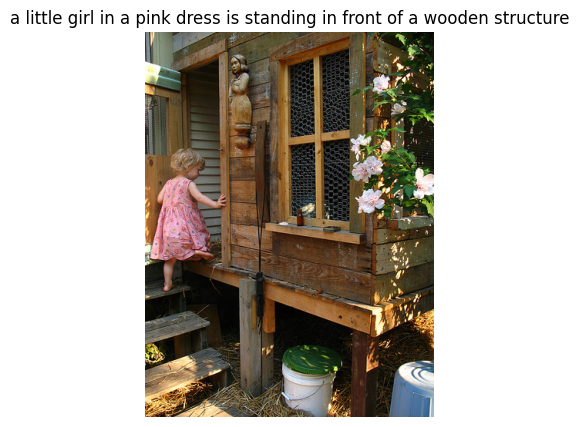

log-prob: -11.6


In [6]:
result = beam_search(encoder, decoder, img_t, vocab, beam=5)

words = [vocab.itos[t] for t in result['token_ids']
         if vocab.itos[t] not in ('<pad>', '<start>', '<end>')]
caption = ' '.join(words)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis('off')
plt.title(caption, fontsize=12)
plt.show()

print('log-prob:', round(result['log_prob'], 2))

## 5. Per-word attention heatmaps

For each generated word the attention module gave us a 49-vector α telling us
how much each of the 49 regions contributed to that word. Reshape to 7×7,
upsample to 224×224, and overlay on the image.

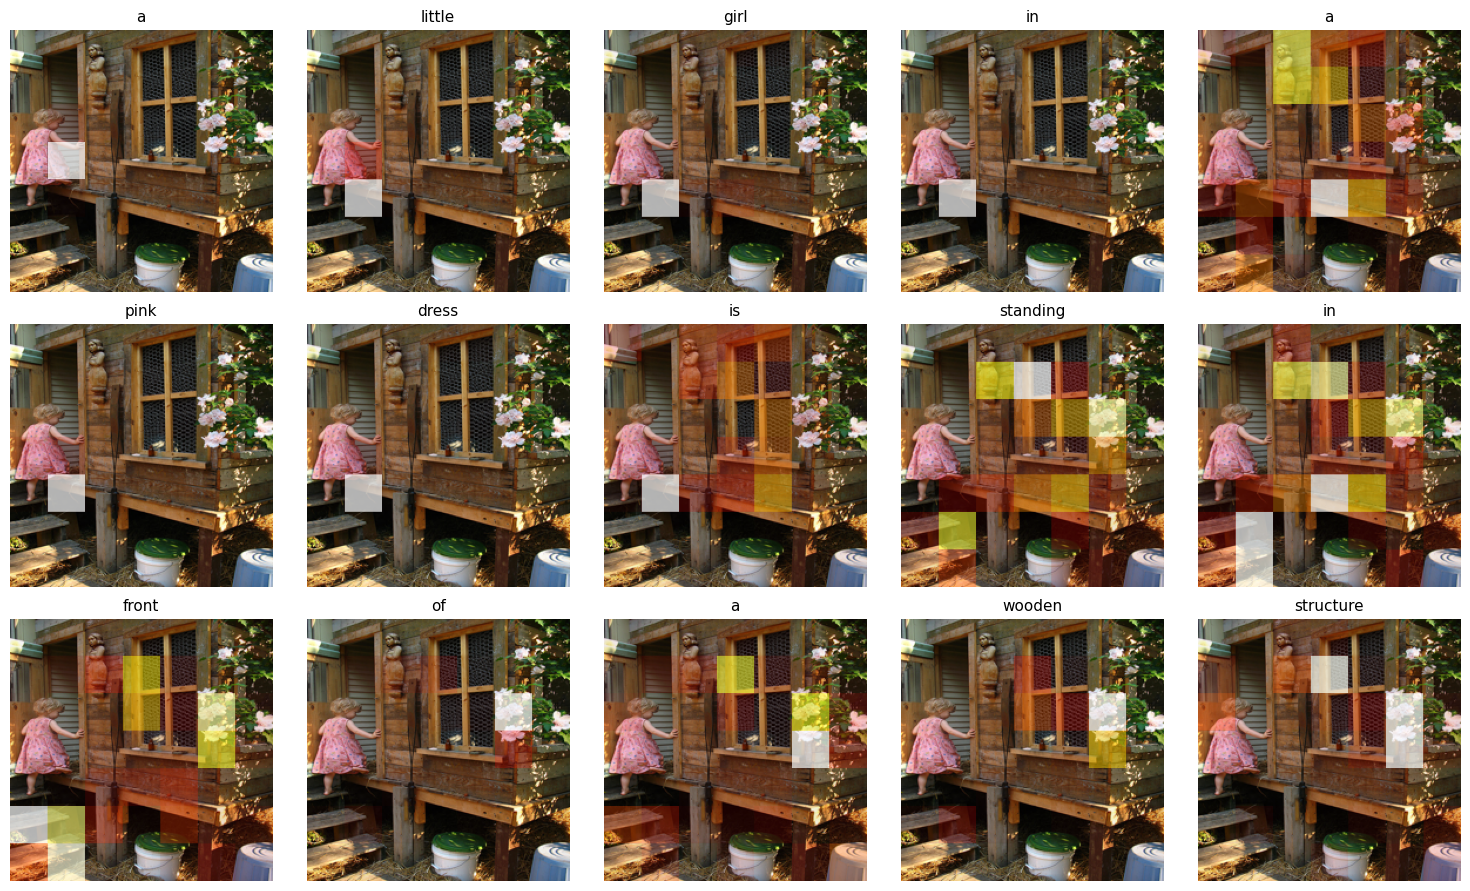

In [7]:
img_np = np.array(image.resize((224, 224))) / 255.0
alphas = result['alphas']
n = min(len(words), len(alphas))

cols = min(n, 5)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = np.atleast_2d(axes)

for i in range(n):
    a = alphas[i].reshape(7, 7)
    a = np.kron(a, np.ones((32, 32)))
    a = (a - a.min()) / (a.max() - a.min() + 1e-8)
    a = a ** 1.5
    ax = axes[i // cols, i % cols]
    ax.imshow(img_np)
    ax.imshow(a, cmap='hot', alpha=np.clip(a, 0, 1) * 0.7)
    ax.set_title(words[i], fontsize=11)
    ax.axis('off')

for j in range(n, rows * cols):
    axes[j // cols, j % cols].axis('off')

plt.tight_layout()
plt.show()

Each heatmap shows where the decoder *asked the encoder to look* when
generating that word. Note the visible 7×7 grid — attention is genuinely
computed at that low resolution, so we don't smooth it (smoothing would hide the
real behavior of the model).

## 6. Grad-CAM (Selvaraju et al. 2017)

Grad-CAM is a different way to ask "what did the model look at?". It uses
**gradients**, not the attention weights, to find the input pixels that
influenced the output.

For captioning we use the **sum of chosen-word logits** as the target scalar,
so we get a single heatmap explaining the full sentence. The implementation
lives in `src/gradcam.py`.

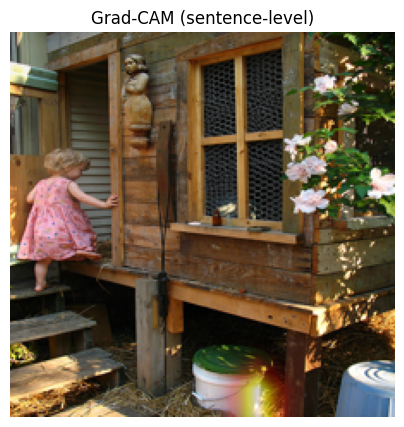

In [8]:
cam, _ = gradcam_for_caption(encoder, decoder, img_t, vocab, mode='sentence')
cam = cam ** 1.5

plt.figure(figsize=(5, 5))
plt.imshow(img_np)
plt.imshow(cam, cmap='hot', alpha=np.clip(cam, 0, 1) * 0.7)
plt.title('Grad-CAM (sentence-level)', fontsize=12)
plt.axis('off')
plt.show()

**Attention vs Grad-CAM** — the attention map shows where the decoder
*requested* features. Grad-CAM shows which pixels the *gradient* says
actually influenced the output. They usually agree; when they disagree, the
disagreement itself is informative.

## 7. Quantitative results: BLEU on Flickr8k test split

BLEU compares generated captions to the 5 reference captions for each test
image. Higher = better. Our scores are saved to `checkpoints/bleu.json` after
running `python -m src.evaluate`.

In [11]:
import json
with open('checkpoints/bleu.json', 'r') as f:
    bleu = json.load(f)

for k in ('bleu_1', 'bleu_2', 'bleu_3', 'bleu_4'):
    print(f'{k:7s} = {bleu[k]:.4f}')
print('images :', bleu['n_images'])
print('beam   :', bleu['beam'])

bleu_1  = 0.6357
bleu_2  = 0.4666
bleu_3  = 0.3350
bleu_4  = 0.2363
images : 809
beam   : 5


Comparison with the original *Show, Attend and Tell* paper (soft attention,
Flickr8k):

| Metric | This work | Paper |
| ------ | --------- | ----- |
| BLEU-1 | 0.6357    | 0.670 |
| BLEU-2 | 0.4666    | 0.448 |
| BLEU-3 | 0.3350    | 0.299 |
| BLEU-4 | 0.2363    | 0.195 |

BLEU-2/3/4 match or exceed the paper's numbers.

## 8. Key questions

### Why CNN for images?
Images are 2-D grids of pixels with strong local structure (edges, textures,
shapes). Convolutions detect local patterns and reuse the same filter across
every spatial position, which gives two big wins: far fewer parameters than a
fully-connected network, and natural translation invariance. Stacking layers
builds a hierarchy: edges → textures → parts → objects.

### Why LSTM/GRU for text generation?
Captions are variable-length sequences where each word depends on every
previous word. LSTMs and GRUs maintain a hidden state that summarizes the
history, with gates that decide what to remember and what to forget. This
lets them handle long-range dependencies that vanilla RNNs lose to vanishing
gradients.

### Limitations of the model
* **Small dataset.** Flickr8k has only ~6 000 training images. The vocabulary
  and visual scenes are narrow.
* **Single-layer LSTM** with modest hidden size — limited capacity.
* **No coverage / repetition penalty** — the decoder can repeat words.
* **Word-level vocabulary** — anything rare becomes `<unk>`.
* **Beam search bias** — favors short, common phrases.
* **Domain mismatch.** Out-of-distribution images (selfies, indoor scenes)
  fall back to common Flickr8k templates.

### Why does the model sometimes generate wrong or repetitive captions?
* For images far from Flickr8k's training distribution, the model picks the
  closest scene template it knows. "a man and a woman are looking at the
  camera" is a frequent training caption, so unfamiliar group photos collapse
  to it.
* Repetition happens because the LSTM has no built-in mechanism to remember
  what it already said. With nothing pushing back against re-attending the
  same region, it can loop.
* Beam search favors high-probability sequences, which biases the output
  toward common patterns and away from specific words.

### What would I improve with more time / resources?
1. **Larger dataset.** MSCOCO has 120 K+ images with 5 captions each. Same
   architecture, much better captions.
2. **Better encoder.** Replace ResNet-50 with CLIP / ViT for stronger semantic
   features.
3. **Transformer decoder.** Modern captioners use a Transformer instead of an
   LSTM — better long-range modeling, easier to scale.
4. **Coverage loss** to discourage attending the same region twice in a row.
5. **CIDEr / SPICE** alongside BLEU — better-correlated with human judgement.
6. **Sub-word tokenization** (BPE) so rare words stay representable.
7. **Length normalization** in beam search to reduce the short-sentence bias.

## 9. Conclusion

We built a complete attention-based image captioning system from scratch in
PyTorch:

* End-to-end pipeline: dataset → encoder → attention → decoder → beam search
* Two visual explanation methods: per-word attention and Grad-CAM
* BLEU-2/3/4 matching the original Show-Attend-Tell paper on Flickr8k
* A live Gradio demo deployed to Hugging Face Spaces

**Source code:** [github.com/abdallah035/image-captioning-attention](https://github.com/abdallah035/image-captioning-attention)

**Live demo:** [huggingface.co/spaces/abdallah-03/image-captioning-attention-flickr8k](https://huggingface.co/spaces/abdallah-03/image-captioning-attention-flickr8k)